#### Test plotting functions using the H2H2 data.

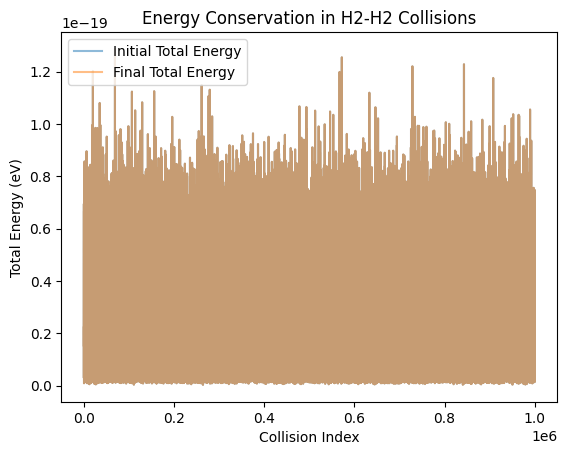

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Check energy conservation
# datafile = "data/H2H2_collisions.csv"
# mdn_path = "results/models/mdn_H2H2.pth"
datafile = "data/filtered/O2O2_collisions.npy"
mdn_path = "results/models/mdn_O2O2.pth"
if ".npy" in datafile:
    data = np.load(datafile)
    data = pd.DataFrame(data, columns=["Etr", "Er1", "Er2", "Etrp", "Er1p", "Er2p"])
elif ".csv" in datafile:
    data = pd.read_csv(datafile, skiprows=1)
else:
    raise ValueError("Unsupported file format. Please provide a .csv or .npy file.")

Etot_init = data.iloc[:,0] + data.iloc[:,1] + data.iloc[:,2]
Etot_final = data.iloc[:,3] + data.iloc[:,4] + data.iloc[:,5]
plt.plot(Etot_init, label='Initial Total Energy', alpha=0.5)
plt.plot(Etot_final, label='Final Total Energy', alpha=0.5)
plt.xlabel('Collision Index')
plt.ylabel('Total Energy (eV)')
plt.title('Energy Conservation in H2-H2 Collisions')
plt.legend()
plt.show()


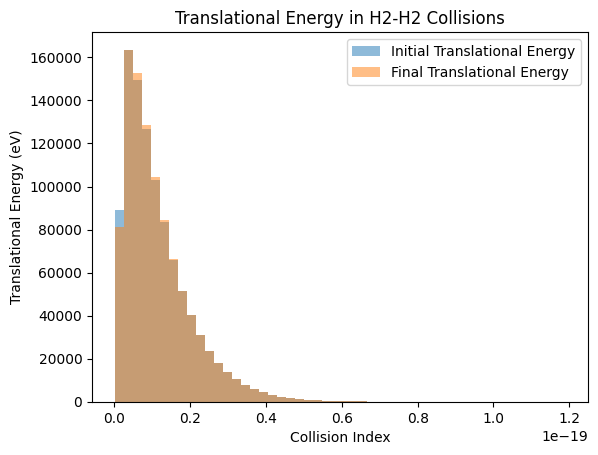

In [5]:
Etr_init = data.iloc[:,0]
Etr_final = data.iloc[:,3]
plt.hist(Etr_init, bins=50, alpha=0.5, label='Initial Translational Energy')
plt.hist(Etr_final, bins=50, alpha=0.5, label='Final Translational Energy')
plt.xlabel('Collision Index')
plt.ylabel('Translational Energy (eV)')
plt.title('Translational Energy in H2-H2 Collisions')
plt.legend()
plt.show()

This indicates the energy distribution nudges toward equilibrium over many collisions.

In [6]:
import torch
from utils.helpers import load_dataset
from machinelearning.mdn import MixtureDensityNetwork
from machinelearning.gmm import GaussianMixtureModel
from config.experiment_config import ExperimentConfig
config = ExperimentConfig()

data = load_dataset(datafile)

# Sample MDN
mdn = MixtureDensityNetwork(input_dim=config.input_dim, output_dim=config.output_dim, num_mixtures=config.num_mixtures, hidden_dim=config.hidden_dim, randomseed=config.random_seed) 
mdn.load_model(mdn_path)
torch.manual_seed(config.random_seed)
mdn_samples = mdn.sample(x=data[0])

# Sample GMM
gmm = GaussianMixtureModel(n_components=config.gmm_n_components, covariance_type=config.gmm_covariance_type)
gmm.fit(data[1])
gmm_samples = gmm.sample(num_samples=config.num_samples)

datasets = {
    "inputs": data[0][:,1:], # Use only the energy fractions for plotting not the total energy
    "CTC": data[1],
    "MDN": mdn_samples,
    # "GMM": gmm_samples
}

Dataset contains 1000000 rows


RuntimeError: Error(s) in loading state_dict for MixtureDensityNetwork:
	Missing key(s) in state_dict: "net.2.weight", "net.2.bias". 
	Unexpected key(s) in state_dict: "net.3.weight", "net.3.bias". 
	size mismatch for pi_layer.weight: copying a param with shape torch.Size([24, 128]) from checkpoint, the shape in current model is torch.Size([5, 128]).
	size mismatch for pi_layer.bias: copying a param with shape torch.Size([24]) from checkpoint, the shape in current model is torch.Size([5]).
	size mismatch for mu_layer.weight: copying a param with shape torch.Size([48, 128]) from checkpoint, the shape in current model is torch.Size([10, 128]).
	size mismatch for mu_layer.bias: copying a param with shape torch.Size([48]) from checkpoint, the shape in current model is torch.Size([10]).
	size mismatch for sigma_layer.weight: copying a param with shape torch.Size([48, 128]) from checkpoint, the shape in current model is torch.Size([10, 128]).
	size mismatch for sigma_layer.bias: copying a pa

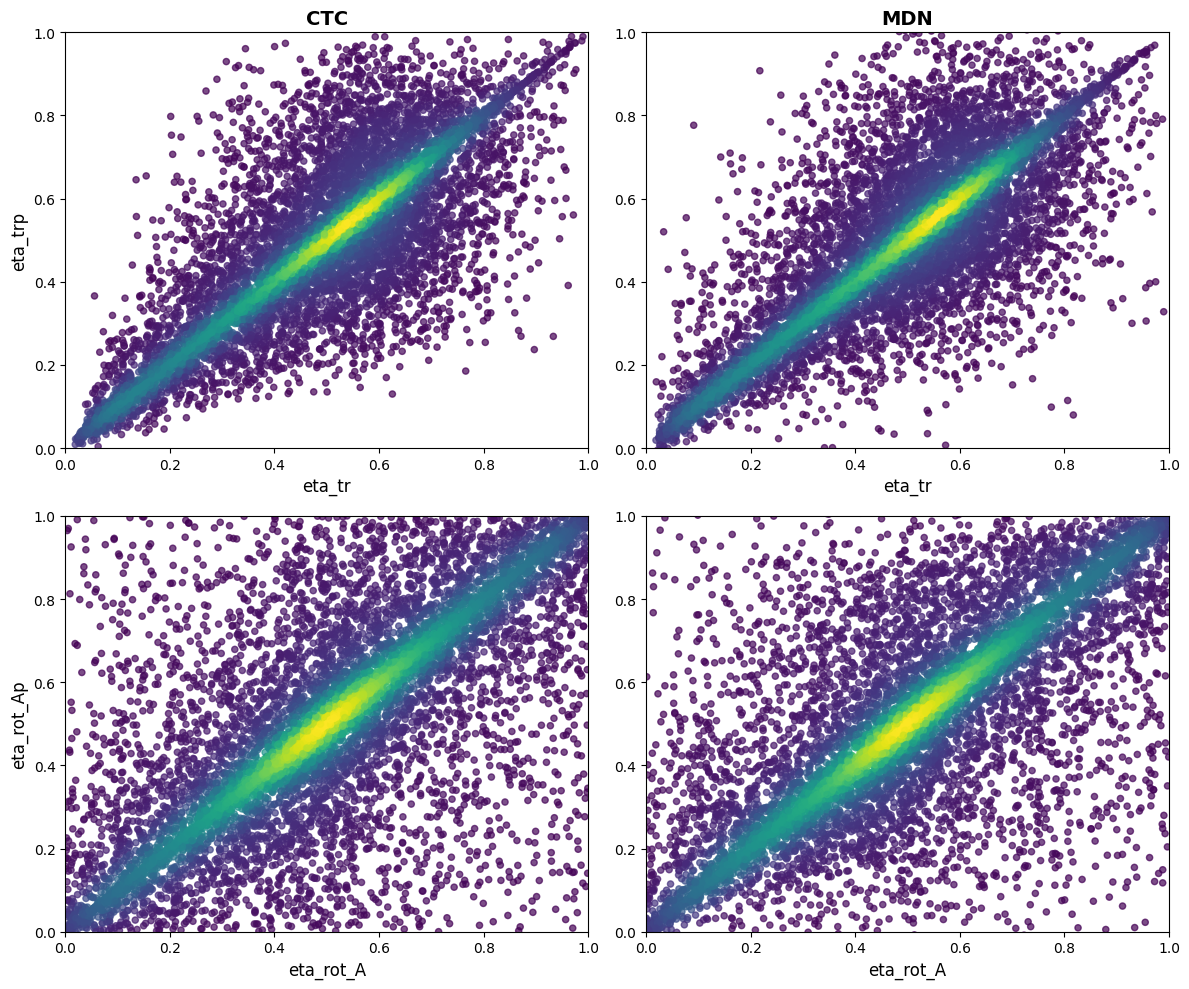

In [ ]:
from visualization.plot import plot_density_scatter, plot_histogram
from config.plotting_config import PlottingConfig
plotting_config = PlottingConfig()
plot_density_scatter(datasets=datasets)

In [ ]:
from analysis.kl_divergence import kl_divergence

kl_ctc_mdn_tr  = kl_divergence(datasets["CTC"][:, 0], datasets["MDN"][:, 0])
kl_ctc_mdn_rot = kl_divergence(datasets["CTC"][:, 1], datasets["MDN"][:, 1])

print(f"KL Divergence (eta_tr):    {kl_ctc_mdn_tr:.4f}")
print(f"KL Divergence (eta_rot_A): {kl_ctc_mdn_rot:.4f}")

KL Divergence (eta_tr):    0.0043
KL Divergence (eta_rot_A): 0.0062
